In [6]:
import numpy as np

l, u, sigma_y_true = np.load("simulations/X_design/scenario_1/l_u_sigma.npy")

input_folder = "simulations/X_design/scenario_1"

X = np.load(f"{input_folder}/X.npy")
ystar = np.load(f"{input_folder}/y_latent.npy")
l, u, sigma_y_true = list(np.load(f"{input_folder}/l_u_sigma.npy"))
beta_true = np.load(f"{input_folder}/beta.npy")
y = np.clip(ystar, l, u).copy()

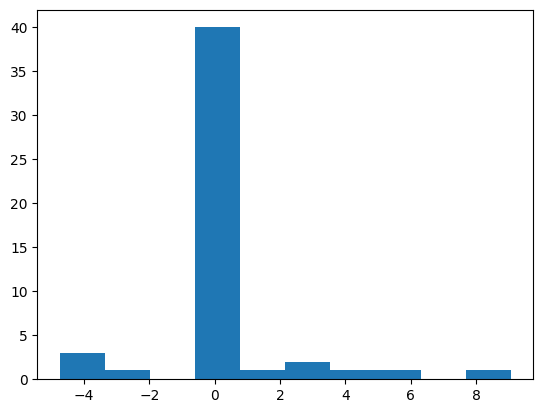

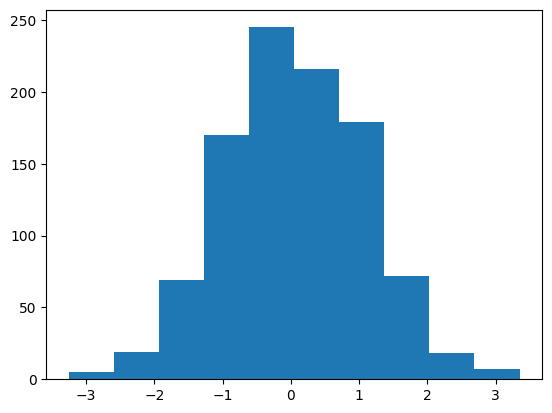

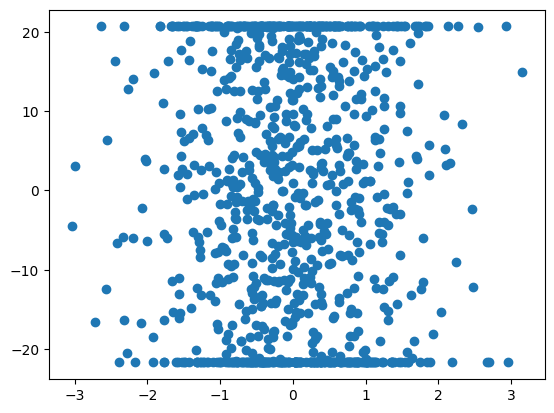

In [7]:
import matplotlib.pyplot as plt

plt.hist(beta_true)
plt.show()
plt.hist(X[:, 1])
plt.show()

plt.scatter(X[:,0],y)

In [14]:
import statsmodels.api as sm

model = sm.OLS(y, X).fit()

model.summary()

((model.pvalues < 0.05) & (beta_true !=0)).sum()

9

In [11]:
beta_nonzero = beta_true[beta_true!=0]
beta_nonzero.std()

4.307256443723094

In [12]:
(beta_true!=0).mean()

0.22

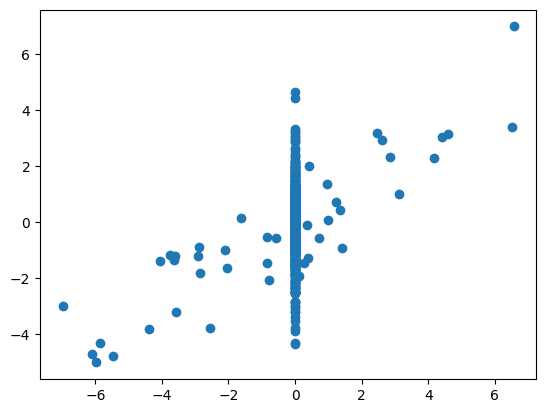

In [16]:
import pandas as pd

df = pd.read_csv("simulations/results/scenario_1_20260813-133734/beta_stats.csv")
plt.scatter(df.true_size, df.beta_cond_mean)